# Noise Statistics of Satellite Data

`NOTE:` Data was *natively* recorded in dBm. Our journey begins in power space. 

In [3]:
import numpy as np
import cmasher as cmr
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [4]:
def read_data(rf_file=None):
    """Convert rf binary data into :class:`~numpy.ndarray` of power and time.

    .. code-block:: python

        from embers.rf_tools.rf_data import read_data
        power, times = read_data(rf_file='~/embers-data/rf.txt')

    :param rf_file: path to rf binary data file :class:`str`

    :returns:
        - power - power in dBm :class:`~numpy.ndarray`
        - times - times in UNIX :class:`~numpy.ndarray`

    """

    with open(rf_file, "rb") as f:
        next(f)
        lines = f.readlines()

        times = []
        data_lines = []

        for line in lines:
            time, data = line.split("$Sp".encode())
            times.append(time.decode())

            # List converts bytes to list of bytes
            # The last two charachters are excluded - Newline char
            data_lines.append(list(data[:-2]))

        # The (-1/2) converts an unsigned byte to a real value
        power = np.single(np.asarray(data_lines) * (-1 / 2))
        times = np.double(np.asarray(times))

        return (power, times)


In [5]:
mwa_sample = "data/S06XX_2019-10-10-02_30.txt"
ref_sample = "data/rf0XX_2019-10-10-02_30.txt"

mwa, _ = read_data(mwa_sample)
ref, _ = read_data(ref_sample)

In [6]:
# Eyeballing satellite chans
bad_range = [[3, 14], [23, 26], [30, 35], [40, 74]]

bad_idx = np.concatenate([np.arange(start, end) for start, end in bad_range])
all_chans = np.arange(112)
good_idx = np.setdiff1d(all_chans, bad_idx)

print(f"Good Chans: [{good_idx.size}], Bad Chans: [{bad_idx.size}]")

Good Chans: [59], Bad Chans: [53]


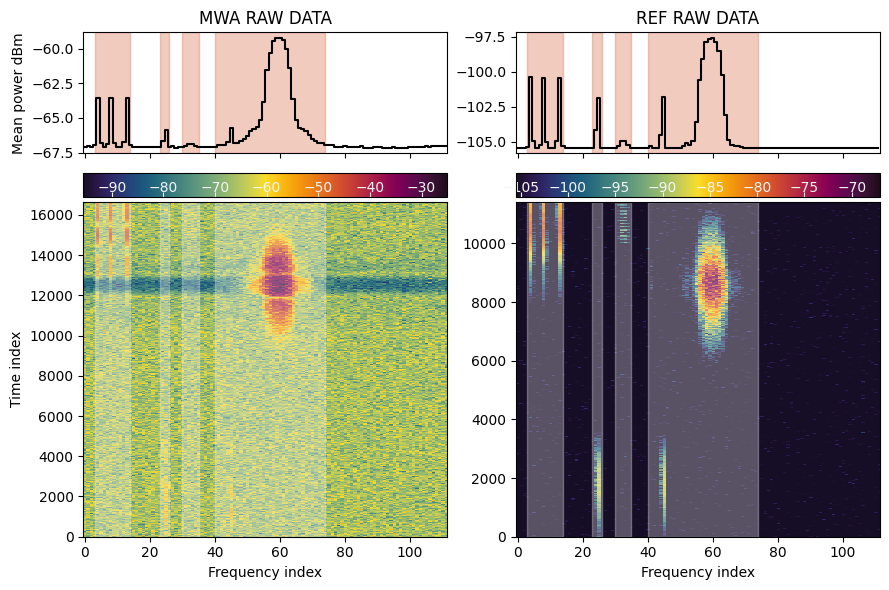

In [7]:
%matplotlib inline

fig, axs = plt.subplots(2, 2, figsize=(9, 6), sharex=True, gridspec_kw=dict(height_ratios=[1, 3]))

axs[0, 0].plot(np.arange(mwa.shape[1]), np.mean(mwa, axis=0), drawstyle="steps-mid", color="k")
axs[0, 1].plot(np.arange(ref.shape[1]), np.mean(ref, axis=0), drawstyle="steps-mid", color="k")

im0 = axs[1, 0].imshow(mwa, origin="lower", interpolation="none", cmap=cmr.pride, aspect="auto")
im1 = axs[1, 1].imshow(ref, origin="lower", interpolation="none", cmap=cmr.pride, aspect="auto")

for b in bad_range:
    axs[1, 0].axvspan(b[0], b[1], color="whitesmoke", alpha=0.3)
    axs[1, 1].axvspan(b[0], b[1], color="whitesmoke", alpha=0.3)
    axs[0, 0].axvspan(b[0], b[1], color=cmr.pride(0.7), alpha=0.3)
    axs[0, 1].axvspan(b[0], b[1], color=cmr.pride(0.7), alpha=0.3)

divider = make_axes_locatable(axs[1, 0])
cax = divider.append_axes("top", size="7%", pad=0.05)
cbar = fig.colorbar(im0, cax=cax, orientation="horizontal")
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.ax.xaxis.set_label_position("bottom")
cbar.ax.tick_params(
    axis="x",
    direction="in",
    pad=-11,
    color="whitesmoke",
    labelcolor="whitesmoke",
)

divider = make_axes_locatable(axs[1, 1])
cax = divider.append_axes("top", size="7%", pad=0.05)
cbar = fig.colorbar(im1, cax=cax, orientation="horizontal")
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.ax.xaxis.set_label_position("bottom")
cbar.ax.tick_params(
    axis="x",
    direction="in",
    pad=-11,
    color="whitesmoke",
    labelcolor="whitesmoke",
)

axs[0, 0].set_title("MWA RAW DATA")
axs[0, 1].set_title("REF RAW DATA")

axs[1, 0].set_ylabel("Time index")
axs[0, 0].set_ylabel("Mean power dBm")
axs[1, 0].set_xlabel("Frequency index")
axs[1, 1].set_xlabel("Frequency index")

plt.tight_layout()
plt.show()

## Let's look at some distributions

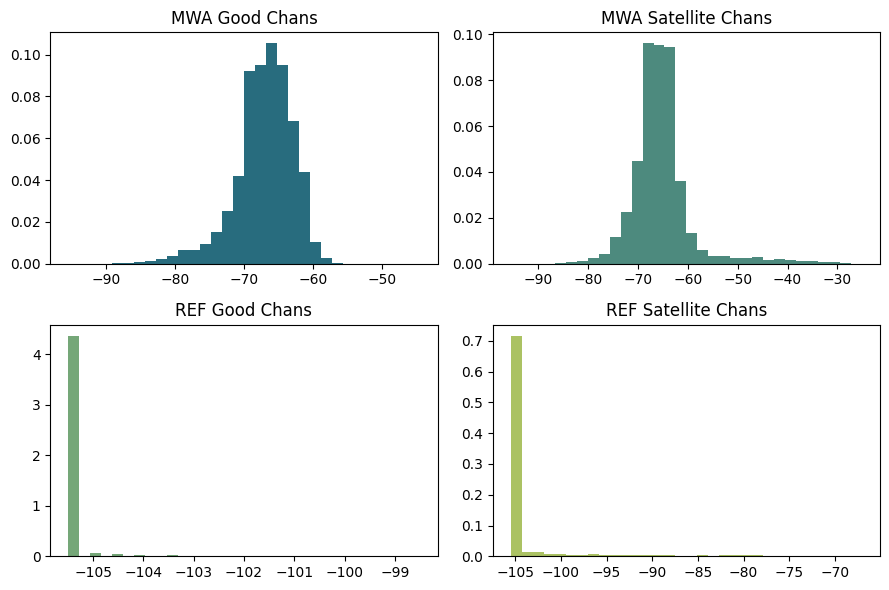

In [17]:
%matplotlib inline

fig, axs = plt.subplots(2, 2, figsize=(9, 6))

axs[0, 0].hist(mwa[:, good_idx].flatten(), bins=32, density=True, color=cmr.pride(0.21))
axs[0, 1].hist(mwa[:, bad_idx].flatten(), bins=32, density=True, color=cmr.pride(0.28))
axs[1, 0].hist(ref[:, good_idx].flatten(), bins=32, density=True, color=cmr.pride(0.35))
axs[1, 1].hist(ref[:, bad_idx].flatten(), bins=32, density=True, color=cmr.pride(0.42))

axs[0, 0].set_title("MWA Good Chans")
axs[0, 1].set_title("MWA Satellite Chans")
axs[1, 0].set_title("REF Good Chans")
axs[1, 1].set_title("REF Satellite Chans")


plt.tight_layout()
plt.show()

## Now individual channels

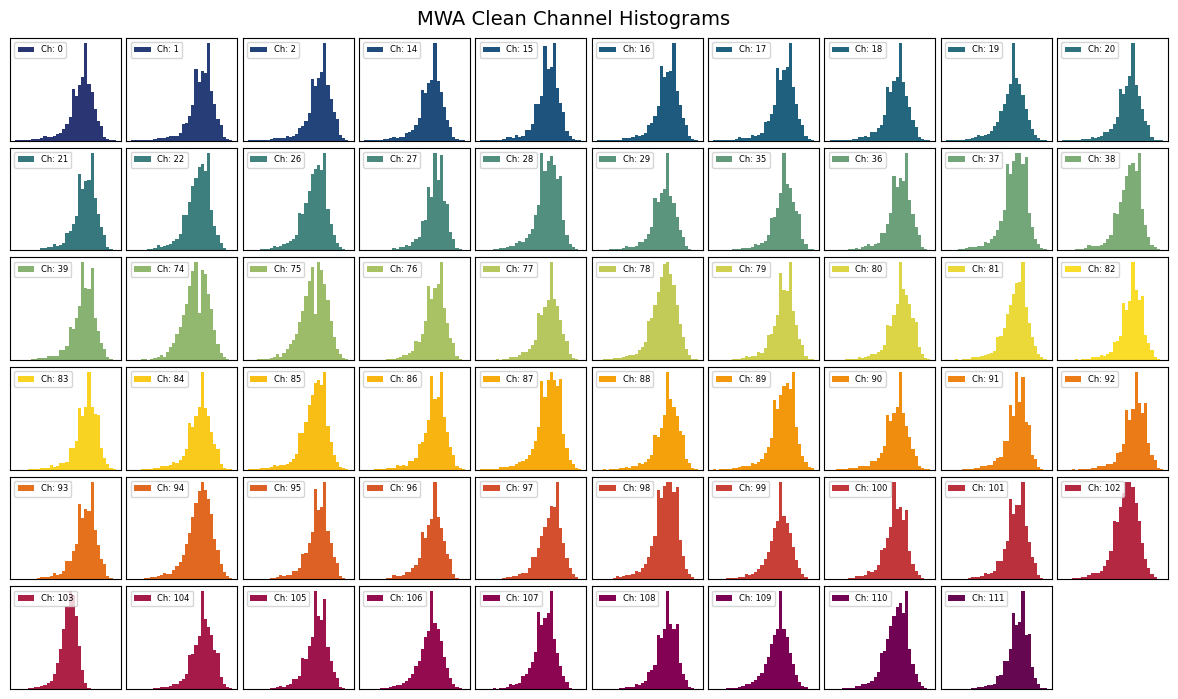

In [6]:
%matplotlib inline

nrows, ncols = 6, 10
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 7))

axs = axs.ravel()

colors = cmr.pride(np.linspace(0.1, 0.9, good_idx.size))

for i, (ch, color) in enumerate(zip(good_idx, colors)):
    ax = axs[i]
    
    ax.hist(
        mwa[:, ch],
        bins=32,
        density=True,
        color=color,
        label=(f"Ch: {ch}")
    )
    
    ax.legend(fontsize=6, loc="upper left")

for j in range(i + 1, nrows * ncols):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )
    
fig.subplots_adjust(
    left=0.03,
    right=0.995,
    top=0.98,
    bottom=0.05,
    wspace=0.05,
    hspace=0.07,
)
fig.suptitle("MWA Clean Channel Histograms", y=1.02, fontsize=14)
plt.show()

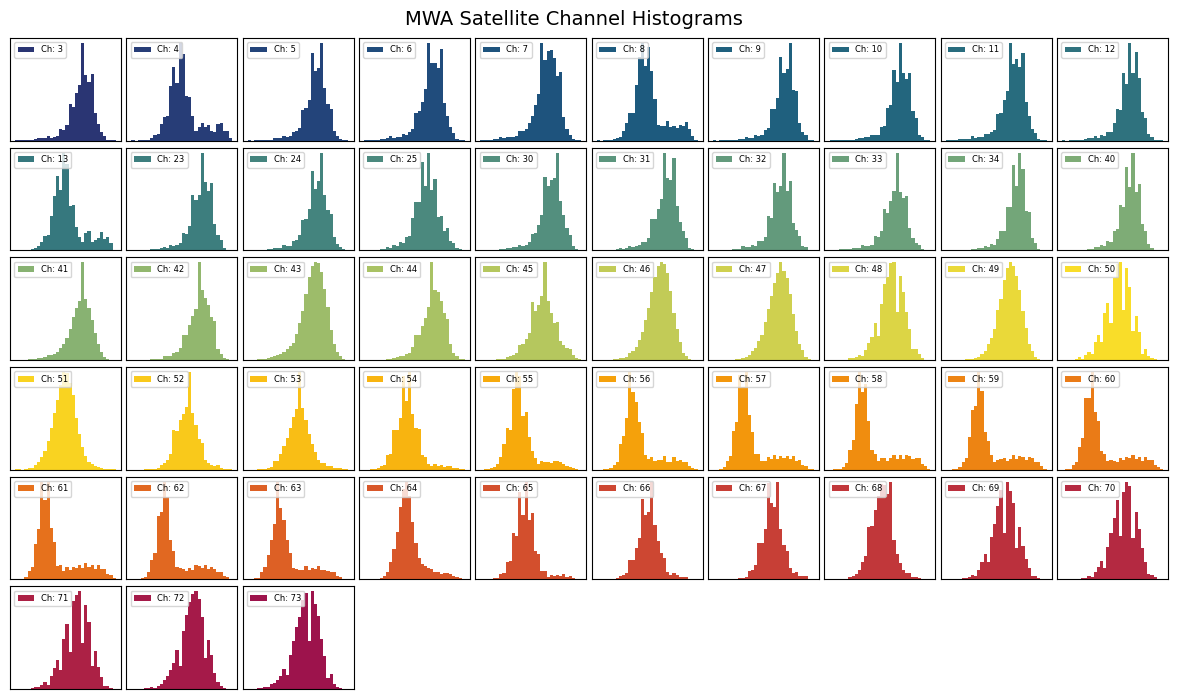

In [7]:
%matplotlib inline

nrows, ncols = 6, 10
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 7))

axs = axs.ravel()

colors = cmr.pride(np.linspace(0.1, 0.9, good_idx.size))

for i, (ch, color) in enumerate(zip(bad_idx, colors)):
    ax = axs[i]
    
    ax.hist(
        mwa[:, ch],
        bins=32,
        density=True,
        color=color,
        label=(f"Ch: {ch}")
    )
    
    ax.legend(fontsize=6, loc="upper left")

for j in range(i + 1, nrows * ncols):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )

fig.subplots_adjust(
    left=0.03,
    right=0.995,
    top=0.98,
    bottom=0.05,
    wspace=0.05,
    hspace=0.07,
)
fig.suptitle("MWA Satellite Channel Histograms", y=1.02, fontsize=14)
plt.show()

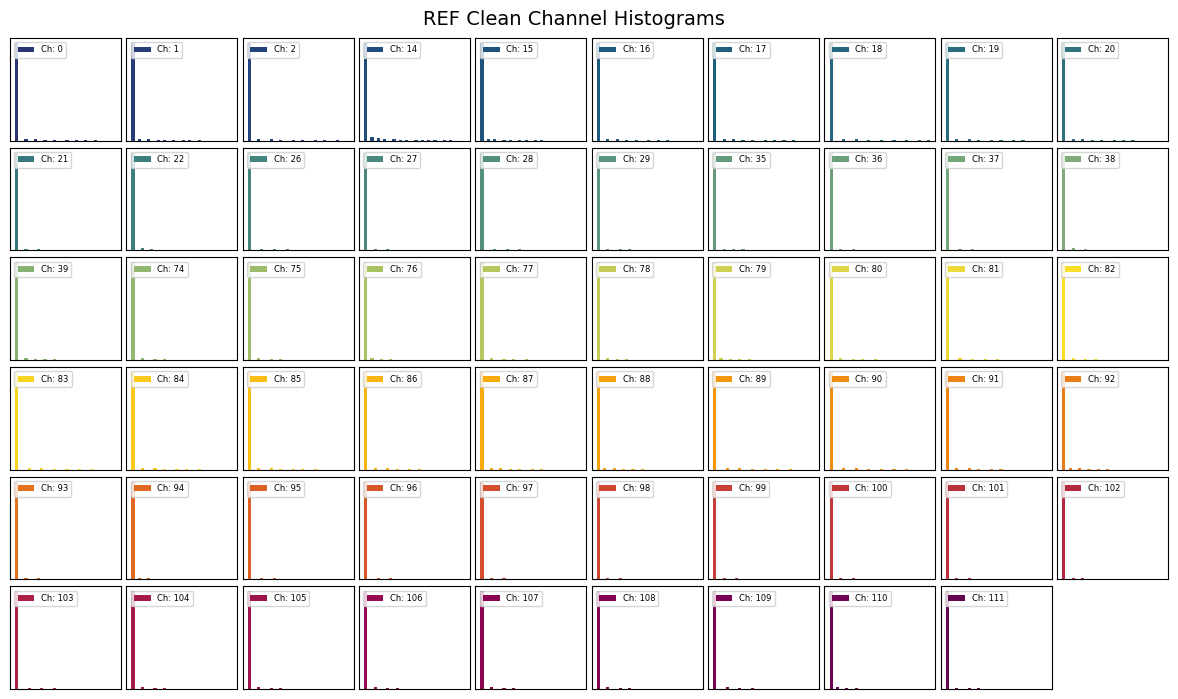

In [8]:
%matplotlib inline

nrows, ncols = 6, 10
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 7))

axs = axs.ravel()

colors = cmr.pride(np.linspace(0.1, 0.9, good_idx.size))

for i, (ch, color) in enumerate(zip(good_idx, colors)):
    ax = axs[i]
    
    ax.hist(
        ref[:, ch],
        bins=32,
        density=True,
        color=color,
        label=(f"Ch: {ch}")
    )
    
    ax.legend(fontsize=6, loc="upper left")

for j in range(i + 1, nrows * ncols):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )

fig.subplots_adjust(
    left=0.03,
    right=0.995,
    top=0.98,
    bottom=0.05,
    wspace=0.05,
    hspace=0.07,
)
fig.suptitle("REF Clean Channel Histograms", y=1.02, fontsize=14)
plt.show()

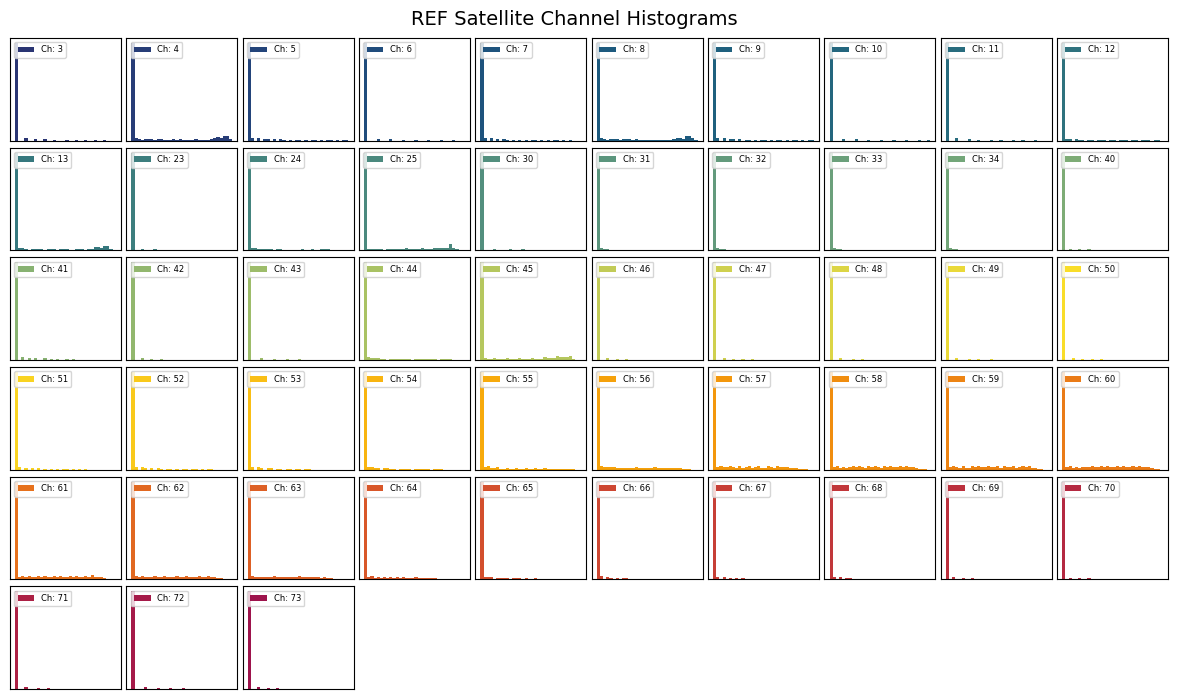

In [9]:
%matplotlib inline

nrows, ncols = 6, 10
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 7))

axs = axs.ravel()

colors = cmr.pride(np.linspace(0.1, 0.9, good_idx.size))

for i, (ch, color) in enumerate(zip(bad_idx, colors)):
    ax = axs[i]
    
    ax.hist(
        ref[:, ch],
        bins=32,
        density=True,
        color=color,
        label=(f"Ch: {ch}")
    )
    
    ax.legend(fontsize=6, loc="upper left")

for j in range(i + 1, nrows * ncols):
    axs[j].axis("off")

for ax in axs:
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )

fig.subplots_adjust(
    left=0.03,
    right=0.995,
    top=0.98,
    bottom=0.05,
    wspace=0.05,
    hspace=0.07,
)
fig.suptitle("REF Satellite Channel Histograms", y=1.02, fontsize=14)
plt.show()